# Análise de Eficiência Temporal: Idade na Coleta (TAT 1) - Otimizado

Esta versão otimizada foca na eficiência de memória e compatibilidade com ambiente local (VS Code).

## Configuração de Ambiente
Certifique-se de ter as bibliotecas `pandas`, `matplotlib`, `seaborn` instaladas no seu ambiente Python.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações opcionais de visualização
plt.style.use('ggplot')

## 1. Carregamento e Otimização de Dados
Carregamos apenas as colunas estritamente necessárias das tabelas para economizar memória e evitar avisos de tipo de dados.

In [ ]:
# Definição de colunas necessárias para a análise TAT
# tb_amostra: chaves para join, data de coleta, unidade e cancelamento
cols_amostra = ['co_seq_amostra', 'co_seq_pessoa', 'dt_col_amostra', 'aut_cancelamento', 'co_seq_unidade_saude']

# tb_pessoa: chave para join e data de nascimento
cols_pessoa = ['co_seq_pessoa', 'dt_nascimento']

print("Carregando datasets...")
try:
    df_amostra = pd.read_csv('./datasets1/tb_amostra.csv', usecols=cols_amostra)
    print(f"Amostras carregadas: {len(df_amostra)} registros")
    
    df_pessoas = pd.read_csv('./datasets2/tb_pessoa.csv', usecols=cols_pessoa)
    print(f"Pessoas carregadas: {len(df_pessoas)} registros")
    
    # Carregamento de dados geográficos e unidades
    df_unidade = pd.read_csv('./datasets1/tb_unidade_saude.csv', usecols=['co_seq_unidade_saude', 'no_unidade_saude', 'co_seq_municipio'])
    df_municipio = pd.read_csv('./datasets1/tb_municipio.csv', usecols=['co_seq_municipio', 'no_municipio'])
    print(f"Tabelas de suporte carregadas.")
except FileNotFoundError as e:
    print(f"Erro ao carregar arquivos: {e}")
    print("Verifique se as pastas './datasets1' e './datasets2' existem no diretório atual.")

Carregando datasets...
Amostras carregadas: 554474 registros
Pessoas carregadas: 544942 registros
Tabelas de suporte carregadas.


## 2. Limpeza e Pré-processamento

In [ ]:
def limpar_data(serie):
    """
    Remove sufixos '.0' e converte para datetime.
    """
    serie_tratada = serie.astype(str).str.replace(r'\.0$', '', regex=True)
    return pd.to_datetime(serie_tratada, format='%Y%m%d', errors='coerce')

# Filtrando apenas amostras válidas (não canceladas) antes de processar
# Regra: aut_cancelamento preenchido indica cancelamento
df_validos = df_amostra[df_amostra['aut_cancelamento'].isna()].copy()
df_cancelados = df_amostra[df_amostra['aut_cancelamento'].notna()].copy()

print(f"Amostras Válidas: {len(df_validos)}")
print(f"Amostras Canceladas: {len(df_cancelados)}")

# Conversão de datas
print("Convertendo datas...")
df_validos['dt_coleta_clean'] = limpar_data(df_validos['dt_col_amostra'])
df_pessoas['dt_nascimento_clean'] = limpar_data(df_pessoas['dt_nascimento'])

Amostras Válidas: 553878
Amostras Canceladas: 596
Convertendo datas...


## 3. Integração e Cálculo do TAT (Turnaround Time)

In [ ]:
# Merge com amostras válidas e dados geográficos
df_validos_geo = pd.merge(df_validos, df_unidade, on='co_seq_unidade_saude', how='left')
df_validos_geo = pd.merge(df_validos_geo, df_municipio, on='co_seq_municipio', how='left')

# Merge final com pessoa para obter data de nascimento
df_tat = pd.merge(
    df_validos_geo[['co_seq_amostra', 'co_seq_pessoa', 'dt_coleta_clean', 'no_unidade_saude', 'no_municipio']],
    df_pessoas[['co_seq_pessoa', 'dt_nascimento_clean']],
    on='co_seq_pessoa',
    how='inner'
)

# Cálculo do TAT em dias
df_tat['tat_dias'] = (df_tat['dt_coleta_clean'] - df_tat['dt_nascimento_clean']).dt.days

# Filtro de Consistência (0 a 365 dias)
df_tat_final = df_tat.query("tat_dias >= 0 and tat_dias <= 365").copy()

# Classificação conforme PNTN
bins = [-1, 2, 5, 30, 365]
labels = ['Precoce (<3 dias)', 'Ideal (3-5 dias)', 'Tardio (6-30 dias)', 'Muito Tardio (>30 dias)']
df_tat_final['status_tat'] = pd.cut(df_tat_final['tat_dias'], bins=bins, labels=labels)

print("Distribuição de Eficiência (TAT):")
print(df_tat_final['status_tat'].value_counts(normalize=True).mul(100).round(2).sort_index())

Distribuição de Eficiência (TAT):
status_tat
Precoce (<3 dias)          13.10
Ideal (3-5 dias)           32.49
Tardio (6-30 dias)         52.72
Muito Tardio (>30 dias)     1.69
Name: proportion, dtype: float64


## 4. Análises Complementares: Geografia e Desempenho
Novos indicadores focados em logística (município) e qualidade (unidade).

In [ ]:
# --- 1. TAT Médio por Município ---
tat_por_municipio = df_tat_final.groupby('no_municipio')['tat_dias'].median().sort_values(ascending=False)

# Top 10 Municípios com maior TAT mediano
print("\nTop 10 Municípios com Maior TAT Mediano (dias):")
print(tat_por_municipio.head(10))

# --- 2. Taxa de Cancelamento por Unidade ---
# Preparar dados de cancelamento (usando df_amostra completo enriquecido)
df_completo = pd.merge(df_amostra, df_unidade, on='co_seq_unidade_saude', how='left')
df_completo['is_cancelado'] = df_completo['aut_cancelamento'].notna()

# Filtrar unidades com relevância estatística (> 100 coletas)
volumetria = df_completo['no_unidade_saude'].value_counts()
unidades_relevantes = volumetria[volumetria > 100].index

df_relevante = df_completo[df_completo['no_unidade_saude'].isin(unidades_relevantes)]

# Calcular taxa
taxa_cancelamento = df_relevante.groupby('no_unidade_saude')['is_cancelado'].mean().mul(100).sort_values(ascending=False)

print("\nTop 10 Unidades com Maior Taxa de Cancelamento (>100 coletas):")
print(taxa_cancelamento.head(10))


Top 10 Municípios com Maior TAT Mediano (dias):
no_municipio
Marajá do Sena             16.0
Santo Amaro do Maranhão    13.0
Raposa                     12.0
Araioses                   11.0
Bom Lugar                  11.0
Grajaú                     11.0
Icatu                      11.0
Brejo                      11.0
Alcântara                  11.0
Presidente Juscelino       11.0
Name: tat_dias, dtype: float64

Top 10 Unidades com Maior Taxa de Cancelamento (>100 coletas):
no_unidade_saude
SOC MED. HOSP.C.REI                 11.309524
SEC.MUNIC. DE ACAILANDIA             6.966618
UBS. DE ALTAMIRA                     2.586207
MARIA CREUZA- APAE                   2.307692
U.B.S. CORINA                        2.083333
U.B.S. JUSSATUBA                     1.550388
U.B.S. RAIMUNILDES DA SILVA REIS     1.388889
U.B.S. FLORIANO C.MATOS              1.337793
U.B.S. PROF. MARIA DO SOCORRO        1.307190
U.B.S JOSÉ DE RIBAMAR BATALHA        1.086957
Name: is_cancelado, dtype: float64


## 5. Visualização dos Resultados

/tmp/ipykernel_58188/937033247.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tat_final, x='status_tat', palette='viridis', ax=axes[1])


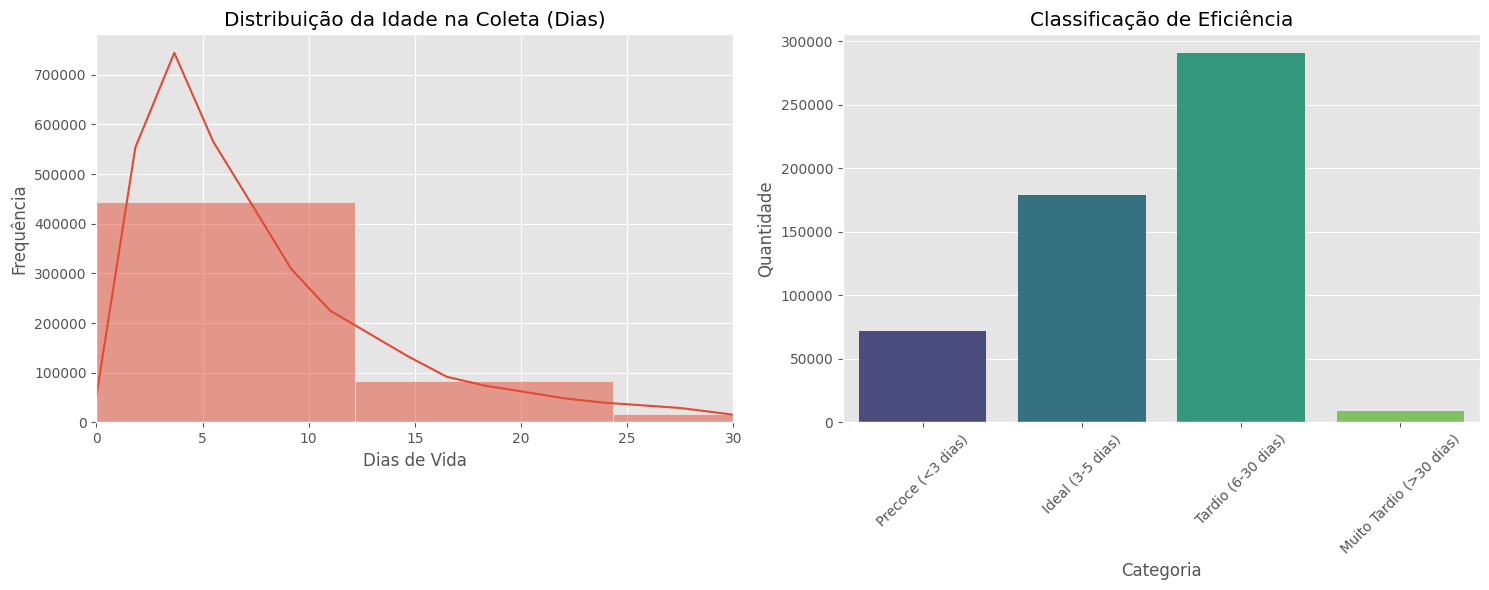

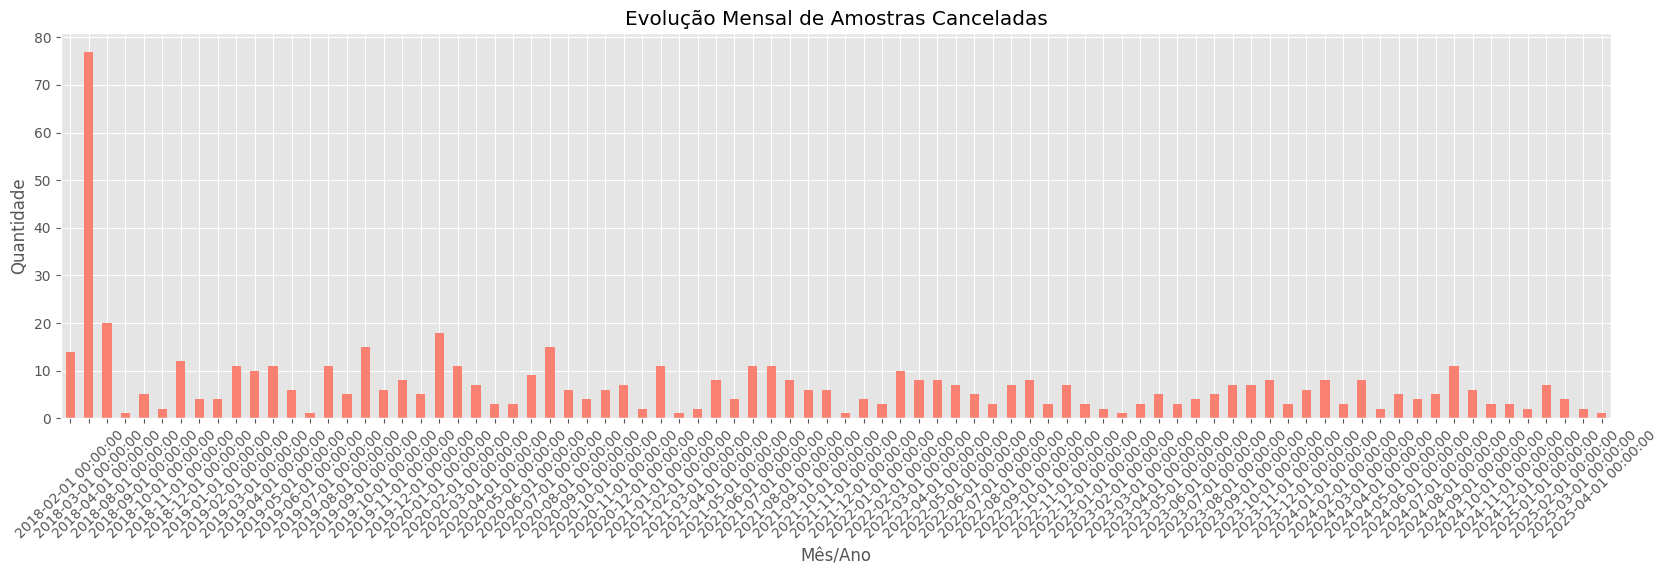

In [ ]:
# Configurar figura
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Histograma do TAT
sns.histplot(data=df_tat_final, x='tat_dias', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição da Idade na Coleta (Dias)')
axes[0].set_xlabel('Dias de Vida')
axes[0].set_ylabel('Frequência')
axes[0].set_xlim(0, 30)

# Gráfico 2: Categorias de TAT
sns.countplot(data=df_tat_final, x='status_tat', palette='viridis', ax=axes[1])
axes[1].set_title('Classificação de Eficiência')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Gráfico 3: Evolução dos Cancelamentos (se houver dados temporais suficientes)
try:
    df_c = df_cancelados.copy()
    df_c['dt_registro'] = pd.to_datetime(df_c['dt_col_amostra'].astype(str).str.slice(0, 6), format='%Y%m', errors='coerce')
    cancelamentos_mes = df_c['dt_registro'].value_counts().sort_index()
    
    plt.figure(figsize=(20, 5))
    cancelamentos_mes.plot(kind='bar', color='salmon')
    plt.title('Evolução Mensal de Amostras Canceladas')
    plt.xlabel('Mês/Ano')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.show()
except Exception as e:
    print(f"Não foi possível gerar gráfico temporal: {e}")

## 5. Análise de Logística: Dias da Semana e Transporte
Investigação do volume de trabalho por dia da semana e gargalos no transporte.

In [ ]:
# Mapeamento de dias da semana
dias_semana = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}

# Extraindo dia da semana (0=Segunda, 6=Domingo)
df_tat_final['dia_semana_coleta'] = df_tat_final['dt_coleta_clean'].dt.dayofweek.map(dias_semana)

# Carregando datas de recebimento (dt_rec_amostra) que não foram carregadas inicialmente
print("Carregando datas de recebimento para análise de logística...")
try:
    df_rec = pd.read_csv('./datasets1/tb_amostra.csv', usecols=['co_seq_amostra', 'dt_rec_amostra'])
    df_rec['dt_rec_clean'] = limpar_data(df_rec['dt_rec_amostra'])
    
    # Merge com df_tat_final
    df_tat_final = pd.merge(df_tat_final, df_rec[['co_seq_amostra', 'dt_rec_clean']], on='co_seq_amostra', how='left')
    
    df_tat_final['dia_semana_rec'] = df_tat_final['dt_rec_clean'].dt.dayofweek.map(dias_semana)
    print("Dados de logística preparados.")
except Exception as e:
    print(f"Erro ao processar datas de recebimento: {e}")

Carregando datas de recebimento para análise de logística...
Dados de logística preparados.


/tmp/ipykernel_58188/3684459971.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tat_final, x='dia_semana_coleta', order=ordem_dias, palette='viridis')
/tmp/ipykernel_58188/3684459971.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tat_final, x='dia_semana_rec', order=ordem_dias, palette='magma')


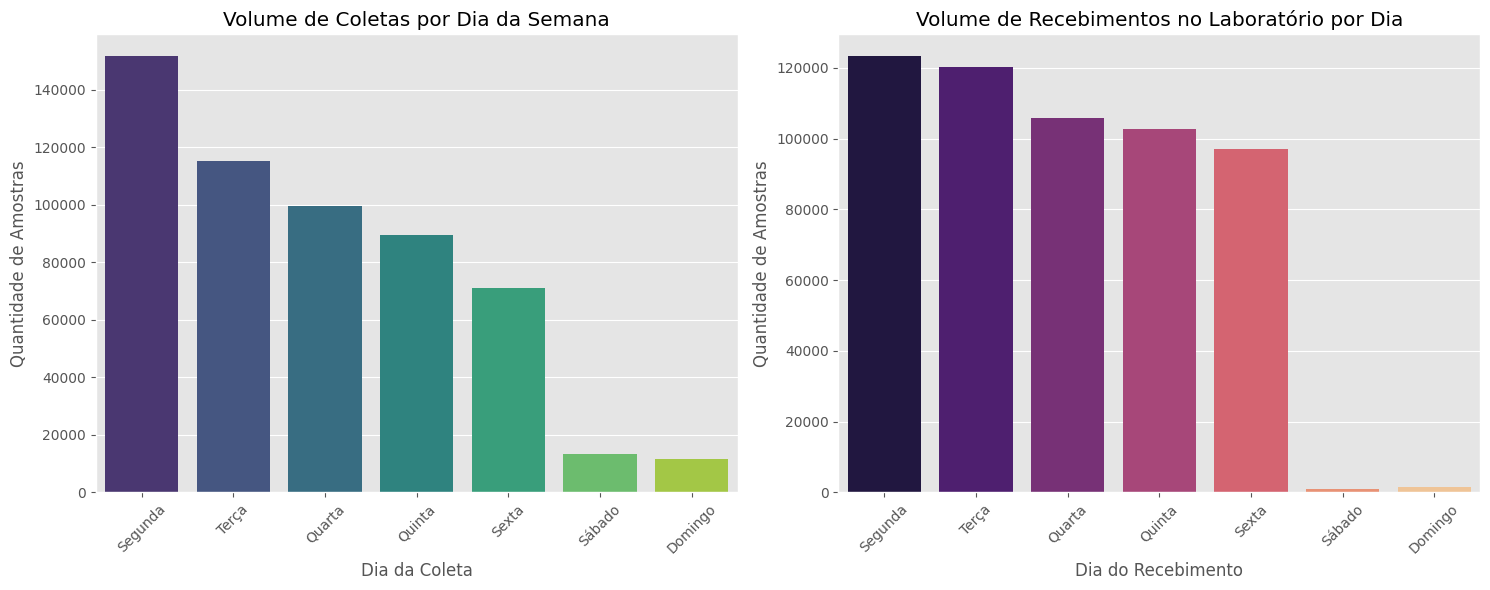

In [ ]:
# Ordem dos dias para plotagem
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(15, 6))

# 1. Volume de Coletas por Dia
plt.subplot(1, 2, 1)
sns.countplot(data=df_tat_final, x='dia_semana_coleta', order=ordem_dias, palette='viridis')
plt.title('Volume de Coletas por Dia da Semana')
plt.xticks(rotation=45)
plt.xlabel('Dia da Coleta')
plt.ylabel('Quantidade de Amostras')

# 2. Volume de Recebimentos por Dia
plt.subplot(1, 2, 2)
sns.countplot(data=df_tat_final, x='dia_semana_rec', order=ordem_dias, palette='magma')
plt.title('Volume de Recebimentos no Laboratório por Dia')
plt.xticks(rotation=45)
plt.xlabel('Dia do Recebimento')
plt.ylabel('Quantidade de Amostras')

plt.tight_layout()
plt.show()

/tmp/ipykernel_58188/1044935923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tat_final, x='dia_semana_coleta', y='tat_dias', order=ordem_dias, estimator=np.median, errorbar=None, palette='coolwarm')


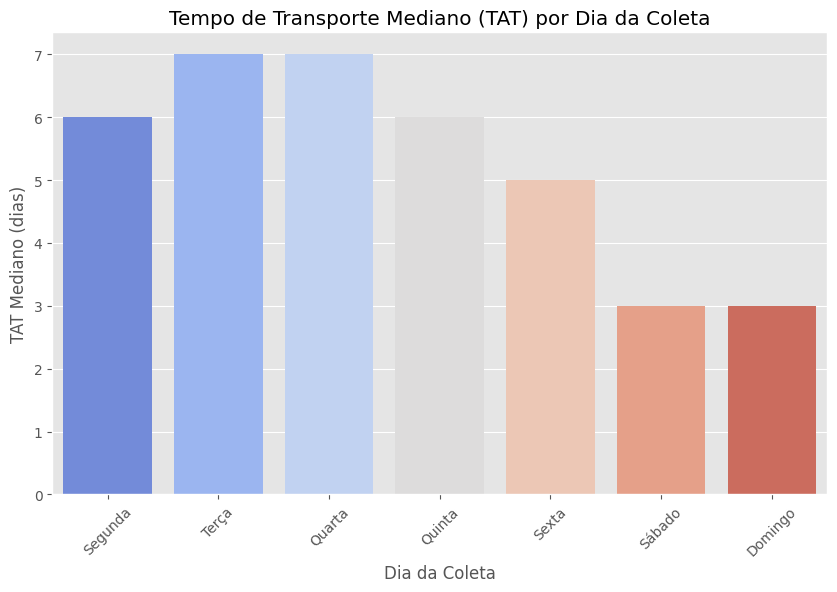

In [ ]:
# TAT Médio por Dia da Coleta
plt.figure(figsize=(10, 6))
sns.barplot(data=df_tat_final, x='dia_semana_coleta', y='tat_dias', order=ordem_dias, estimator=np.median, errorbar=None, palette='coolwarm')
plt.title('Tempo de Transporte Mediano (TAT) por Dia da Coleta')
plt.xticks(rotation=45)
plt.xlabel('Dia da Coleta')
plt.ylabel('TAT Mediano (dias)')
plt.show()

## 6. Conclusão da Análise
A análise acima permite identificar:
1. A eficiência geral do programa (proporção de coletas ideais).
2. Municípios com maiores desafios logísticos (alto TAT mediano).
3. Unidades de saúde que necessitam de retreinamento (alta taxa de cancelamento).